# Diagnóstico post-hoc: clustering con encoder de dos etapas

Seleccionamos el checkpoint de menor error de cada seed sin filtrar por rango y medimos clustering en validation. El resultado es descriptivo: no cambia el FAIL formal ni autoriza test.

In [1]:
# ruff: noqa: E402, E501
import json
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import (
    PaperCheckpointReplayConfig,
    load_paper_mlp_one_hidden_development_config,
)
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import (
    evaluate_paper_mlp_clustering_gate,
    evaluate_paper_mlp_seed_clustering,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    make_paper_loader,
    run_paper_train_validation_with_checkpoint,
    summarize_seed_checkpoint,
    verify_paper_checkpoint_replay,
)

plt.style.use("seaborn-v0_8-whitegrid")
torch.use_deterministic_algorithms(True)

In [2]:
config = load_paper_mlp_one_hidden_development_config(
    ROOT / "configs" / "paper_mlp_two_stage_one_hidden_development.yaml"
)
diagnostic_gate = replace(config.checkpoint_gate, min_validation_effective_rank=1.0)
replay_config = PaperCheckpointReplayConfig(metric_absolute_tolerance=1e-8)
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
assert config.model.encoder_projection == "two_stage"
assert len(train_dataset) == 64 * len(PAPER_REGIME_NAMES) == 1152
assert len(validation_dataset) == 32 * len(PAPER_REGIME_NAMES) == 576
assert {train_dataset.sample_key(i) for i in range(len(train_dataset))}.isdisjoint(
    {validation_dataset.sample_key(i) for i in range(len(validation_dataset))}
)
print(f"Rango formal={config.checkpoint_gate.min_validation_effective_rank}; selección descriptiva={diagnostic_gate.min_validation_effective_rank}")
print("Test no fue instanciado.")

Rango formal=4.0; selección descriptiva=1.0
Test no fue instanciado.


In [3]:
models, summaries, times = {}, [], {}
for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(config.model)
    started = time.perf_counter()
    run = run_paper_train_validation_with_checkpoint(
        model, train_dataset, validation_dataset, run_config, diagnostic_gate
    )
    assert run.selection is not None
    replay = verify_paper_checkpoint_replay(
        model, run, validation_dataset, run_config, replay_config, expected_epoch=run.selection.epoch
    )
    assert replay.passed
    times[seed] = time.perf_counter() - started
    models[seed] = model
    summary = summarize_seed_checkpoint(seed, run.selection)
    summaries.append(summary)
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"seed={seed} epoch={summary.checkpoint_epoch} val/base={summary.validation_loss_ratio:.3f} "
        f"rank={summary.validation_effective_rank:.2f} formal_rank={'PASS' if formal_rank else 'FAIL'}"
    )
print(f"Cinco checkpoints reproducidos; tiempo={sum(times.values()):.1f}s")

@torch.no_grad()
def collect_embeddings(model, run_config):
    device = torch.device(run_config.device)
    model.to(device).eval()
    embeddings, labels = [], []
    for context, _, batch_labels in make_paper_loader(validation_dataset, run_config, shuffle=False):
        embeddings.append(model.online_encoder(context.to(device)).cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

clustering_metrics, reference_labels = [], None
for seed in config.sweep.seeds:
    embeddings, labels = collect_embeddings(models[seed], replace(config.train, seed=seed))
    reference_labels = labels if reference_labels is None else reference_labels
    assert np.array_equal(labels, reference_labels)
    clustering_metrics.append(
        evaluate_paper_mlp_seed_clustering(embeddings, labels, seed, config.clustering)
    )
clustering_gate = evaluate_paper_mlp_clustering_gate(
    clustering_metrics, config.sweep, config.clustering_gate
)
print(json.dumps(asdict(clustering_gate), indent=2))

seed=10 epoch=7 val/base=0.002 rank=3.36 formal_rank=FAIL


seed=11 epoch=7 val/base=0.002 rank=1.22 formal_rank=FAIL


seed=12 epoch=8 val/base=0.002 rank=2.91 formal_rank=FAIL


seed=13 epoch=7 val/base=0.002 rank=1.48 formal_rank=FAIL


seed=14 epoch=7 val/base=0.001 rank=1.89 formal_rank=FAIL
Cinco checkpoints reproducidos; tiempo=208.4s


{
  "all_seeds_present": true,
  "all_finite": true,
  "overall_mean_purity": 0.47897569444444443,
  "worst_seed_mean_purity": 0.45234375,
  "seed_mean_purity_coefficient_of_variation": 0.040326611932921745,
  "worst_within_seed_purity_std": 0.013779954745128088,
  "failed_seeds": [
    10,
    11,
    12,
    13,
    14
  ],
  "overall_mean_passed": false,
  "worst_seed_passed": false,
  "seed_variability_passed": true,
  "kmeans_stability_passed": true,
  "metrics": [
    {
      "seed": 10,
      "mean_purity": 0.48081597222222233,
      "purity_std": 0.012245122859904945,
      "minimum_purity": 0.4496527777777778,
      "maximum_purity": 0.5,
      "mean_matched_accuracy": 0.46345486111111117,
      "purities": [
        0.4930555555555556,
        0.4878472222222222,
        0.4930555555555556,
        0.4913194444444444,
        0.4791666666666667,
        0.4791666666666667,
        0.4600694444444444,
        0.4774305555555556,
        0.4774305555555556,
        0.4809027777

seed epoch rank formal_rank purity_mean purity_sd purity_min purity_max
  10     7  3.36       False      48.08%     1.22%     44.97%     50.00%
  11     7  1.22       False      51.22%     1.38%     49.13%     53.65%
  12     8  2.91       False      47.19%     0.81%     45.83%     48.61%
  13     7  1.48       False      47.77%     0.99%     45.66%     49.83%
  14     7  1.89       False      45.23%     0.80%     43.92%     46.88%


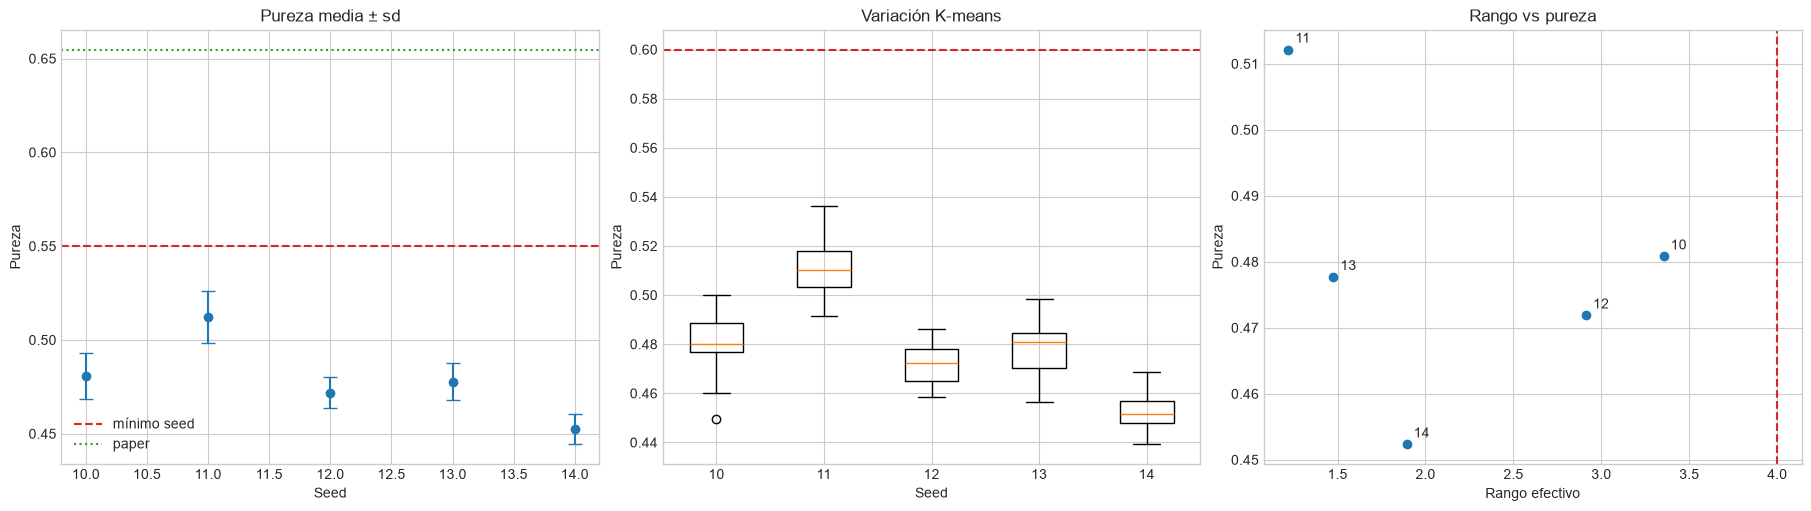

## Resultado descriptivo

- **FAIL descriptivo.**
- Pureza global: **47.90%**.
- Peor seed: **45.23%**.
- CV entre seeds: **0.040**.
- Mayor sd de K-means: **1.38%**.

Este resultado no modifica el FAIL formal y test no fue construido.


In [4]:
summary_by_seed = {row.seed: row for row in summaries}
cluster_by_seed = {row.seed: row for row in clustering_metrics}
print("seed epoch rank formal_rank purity_mean purity_sd purity_min purity_max")
for seed in config.sweep.seeds:
    summary, cluster = summary_by_seed[seed], cluster_by_seed[seed]
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"{seed:>4d} {summary.checkpoint_epoch:>5d} {summary.validation_effective_rank:>5.2f} "
        f"{str(formal_rank):>11s} {cluster.mean_purity:>11.2%} {cluster.purity_std:>9.2%} "
        f"{cluster.minimum_purity:>10.2%} {cluster.maximum_purity:>10.2%}"
    )

seeds = np.array(config.sweep.seeds)
means = np.array([cluster_by_seed[seed].mean_purity for seed in seeds])
stds = np.array([cluster_by_seed[seed].purity_std for seed in seeds])
ranks = np.array([summary_by_seed[seed].validation_effective_rank for seed in seeds])
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].errorbar(seeds, means, yerr=stds, fmt="o", capsize=5)
axes[0].axhline(config.clustering_gate.min_worst_seed_mean_purity, color="tab:red", linestyle="--", label="mínimo seed")
axes[0].axhline(0.6548, color="tab:green", linestyle=":", label="paper")
axes[0].set(title="Pureza media ± sd", xlabel="Seed", ylabel="Pureza")
axes[0].legend()
axes[1].boxplot([cluster_by_seed[seed].purities for seed in seeds], tick_labels=seeds)
axes[1].axhline(config.clustering_gate.min_overall_mean_purity, color="tab:red", linestyle="--")
axes[1].set(title="Variación K-means", xlabel="Seed", ylabel="Pureza")
axes[2].scatter(ranks, means)
for seed, rank, mean in zip(seeds, ranks, means, strict=True):
    axes[2].annotate(str(seed), (rank, mean), xytext=(5, 5), textcoords="offset points")
axes[2].axvline(config.checkpoint_gate.min_validation_effective_rank, color="tab:red", linestyle="--")
axes[2].set(title="Rango vs pureza", xlabel="Rango efectivo", ylabel="Pureza")
plt.show()

status = "PASS descriptivo" if clustering_gate.passed else "FAIL descriptivo"
display(Markdown(f"""## Resultado descriptivo

- **{status}.**
- Pureza global: **{clustering_gate.overall_mean_purity:.2%}**.
- Peor seed: **{clustering_gate.worst_seed_mean_purity:.2%}**.
- CV entre seeds: **{clustering_gate.seed_mean_purity_coefficient_of_variation:.3f}**.
- Mayor sd de K-means: **{clustering_gate.worst_within_seed_purity_std:.2%}**.

Este resultado no modifica el FAIL formal y test no fue construido.
"""))

## Análisis posterior a la corrida

El encoder de dos etapas obtiene pureza global `47.90%`, `2.86` puntos por debajo del encoder directo con el mismo predictor (`50.76%`) y `17.58` puntos por debajo del `65.48%` publicado. Las medias por seed van de `45.23%` a `51.22%`; las cinco fallan el mínimo local por seed de `55%`.

El resultado vuelve a ser estable pero bajo: CV entre seeds `0.040` y peor desviación por inicialización de K-means `1.38%`. Todos los checkpoints de mínimo error quedan por debajo de rango 4 (`1.22–3.36`). Seed 11 vuelve a tener la mejor pureza pese al menor rango, lo que refuerza que rango y separación de clases no están alineados de forma simple.

La proyección `6144→64→32` no explica el resultado del paper: empeora tanto la dimensionalidad como la pureza. Con las dos lecturas del predictor y las dos lecturas principales del encoder ya evaluadas, seguir combinando capas sin una hipótesis sería poco informativo. La siguiente sensibilidad debe abordar la optimización no especificada por el paper. Una prueba limpia es volver a la mejor arquitectura observada (encoder directo y predictor `32→64→32`) y bajar sólo el learning rate de `3e-4` a `1e-4`, manteniendo el resto fijo.